In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy  as np
import tensorflow as tf
import math

from model.exp import Exp

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from tqdm import tqdm

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
# EXP
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 0
d_ff= 2048
E_LAYERS = 2
D_LAYERS = 1
PRED_LEN =24
FEATURES= 4
TIME_FEATURES = 3
EPOCHS = 30
EMBED_FREQ = 'r'
DATA_SOURCE = 'GAS'
settings = {'batch_size':BATCH_SIZE, 'seq_len':SEQ_LEN, 'global_size':GLOBAL_SIZE, 'd_model':d_model, 'd_ff':d_ff, 'e_layer': E_LAYERS,
            'd_layer':D_LAYERS, 'rate':RATE, 'factor':FACTOR, 'heads':HEADS, 'pred_len':PRED_LEN, 'features':FEATURES, 'timeFeatures':TIME_FEATURES, 'freq':EMBED_FREQ,
            'data_source':DATA_SOURCE}
# print(settings)
# Creation du model Exp
myExpFct = Exp(settings)
myExpFct.build(split=0.2)
myExpFct._buildModel(LR=0.000_15)
model = myExpFct.train(EPOCHS)

Epoch: 0 -> loss=18.05/0.48 -> Accuracy=51.93%/90.08% - [94.59s]
Epoch: 1 -> loss=1.86/0.47 -> Accuracy=65.53%/90.67% - [96.65s]
Epoch: 2 -> loss=1.03/0.43 -> Accuracy=71.90%/91.09% - [93.88s]
Epoch: 3 -> loss=0.60/0.42 -> Accuracy=76.03%/90.87% - [111.91s]
Epoch: 4 -> loss=0.40/0.40 -> Accuracy=78.97%/90.88% - [749.59s]
Epoch: 5 -> loss=0.31/0.38 -> Accuracy=81.14%/91.29% - [216.15s]
Epoch: 6 -> loss=0.26/0.36 -> Accuracy=82.80%/91.58% - [103.30s]
Epoch: 7 -> loss=0.21/0.33 -> Accuracy=84.16%/92.00% - [96.57s]
Epoch: 8 -> loss=0.20/0.31 -> Accuracy=85.23%/92.29% - [92.62s]
Epoch: 9 -> loss=0.20/0.32 -> Accuracy=86.08%/92.08% - [93.76s]
Epoch:10 -> loss=0.16/0.31 -> Accuracy=86.85%/92.19% - [99.74s]
Epoch:11 -> loss=0.14/0.29 -> Accuracy=87.52%/92.50% - [91.44s]
Epoch:12 -> loss=0.15/0.28 -> Accuracy=88.07%/92.61% - [95.96s]
Epoch:13 -> loss=0.13/0.27 -> Accuracy=88.57%/92.77% - [103.48s]
Epoch:14 -> loss=0.11/0.26 -> Accuracy=89.04%/92.81% - [92.71s]
Epoch:15 -> loss=0.11/0.25 -> Accu

count    2846.000000
mean        2.016163
std         1.402140
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: sJour, dtype: float64


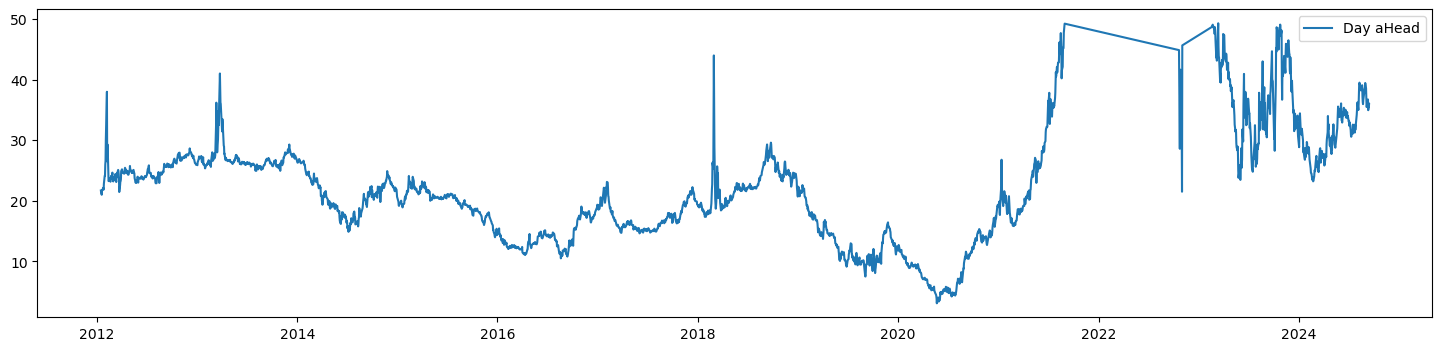

In [3]:
myExpFct.dataFct.display()
print(myExpFct.dataFct.df_Data['sJour'].describe())

Saved checkpoint


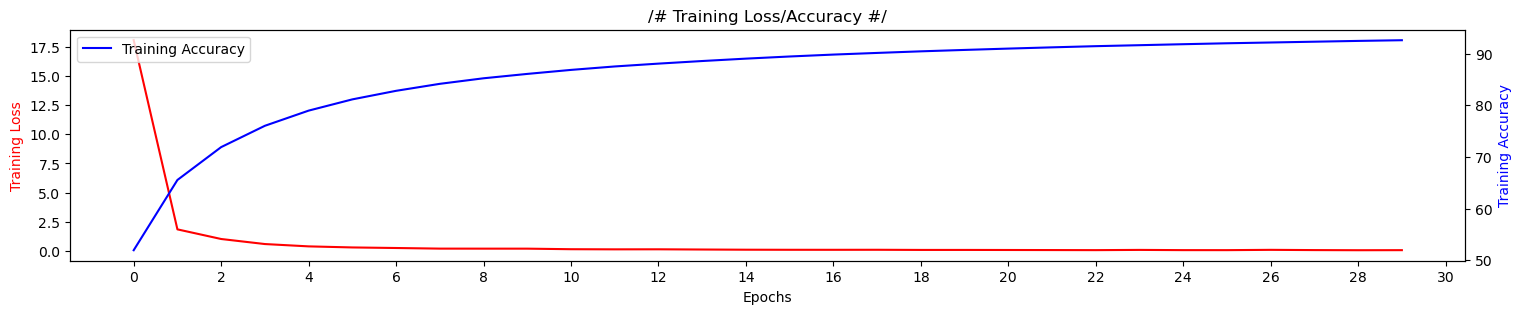

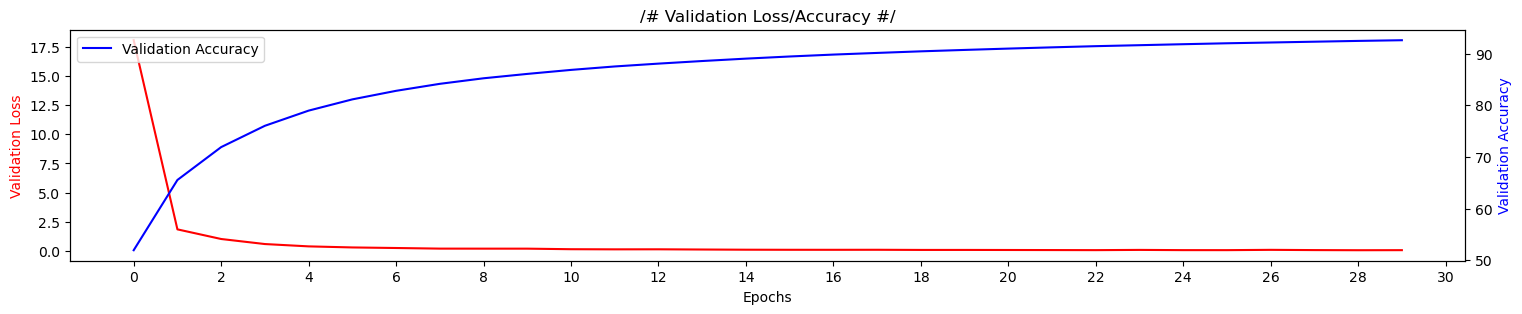

In [10]:
myExpFct.save_model()
myExpFct.drawTrain()
myExpFct.drawValid()

In [5]:
def getData(data,init,seq_len=96,pred_len=24):
    f = 4
    dec_len = seq_len//2
    dec_all = dec_len + pred_len
    Xe = data[init:init+seq_len,0:f]
    Xed = data[init:init+seq_len,f:]
    padd = tf.zeros((pred_len,7))
    Xd = tf.concat([data[init:init+dec_len,:f],padd[:,:f]],axis=0)
    Xdd = tf.concat([data[init:init+dec_len,f:],padd[:,f:]],axis=0)
    Xe = tf.reshape(Xe, shape=(1,seq_len,f))
    Xed = tf.reshape(Xed, shape=(1,seq_len,3))
    Xd = tf.reshape(Xd, shape=(1,dec_all,f))
    Xdd = tf.reshape(Xdd, shape=(1,dec_all,3))
    Xr = data[init:init+dec_all,:f]
    Xr = tf.reshape(Xr, shape=(dec_all,f))
    return Xe,Xed,Xd,Xdd,Xr


In [5]:
myExpFct.X_date_enc

<tf.Tensor: shape=(18, 96, 3), dtype=float32, numpy=
array([[[-0.9938004 , -0.92560446, -0.98760074],
        [-0.9938004 , -0.91940486, -0.98140115],
        [-0.9938004 , -0.9132052 , -0.9752015 ],
        ...,
        [-0.9690019 , -0.8512089 , -0.9938004 ],
        [-0.9690019 , -0.8450093 , -0.98760074],
        [-0.9690019 , -0.83880967, -0.98140115]],

       [[-0.9380037 , -0.8512089 , -0.98140115],
        [-0.9380037 , -0.8450093 , -0.9752015 ],
        [-0.9380037 , -0.8264104 , -1.        ],
        ...,
        [-0.98140115, -0.95660263, -0.9752015 ],
        [-0.98140115, -0.9380037 , -1.        ],
        [-0.98140115, -0.9318041 , -0.9938004 ]],

       [[-0.9752015 , -0.9752015 , -1.        ],
        [-0.9752015 , -0.9690019 , -0.9938004 ],
        [-0.9752015 , -0.96280223, -0.98760074],
        ...,
        [-0.950403  , -0.92560446, -0.9752015 ],
        [-0.950403  , -0.9070056 , -1.        ],
        [-0.950403  , -0.90080595, -0.9938004 ]],

       ...,

       

In [8]:
# # Creation du model Exp
# myExpFct = Exp(settings)
# myExpFct.build()
# # Chargement du model
# new_modelExp = Exp(settings=settings)
# new_model = new_modelExp.modelFct
# new_model.load_weights('weights/wghts20.ckpt')

new_model = myExpFct.modelFct

# Prédictions ...
init = 00
forecast = 1000

data = myExpFct.dataFct.dataN
_,_,_,_,Xi = getData(data,init,SEQ_LEN,PRED_LEN)
Xi = Xi[:,:]
Pi = tf.cast(Xi,tf.float32)
Pimin = Pi
Pimax = Pi
Pia = Pi
Pall = Pi
Mall = Pi[None,-PRED_LEN:,:]
infM = tf.ones(shape=(1,1,FEATURES),dtype=tf.float32) * -1.e10
infm = tf.ones(shape=(1,1,FEATURES),dtype=tf.float32) * 1.e10
# for i in (range (forecast)):
for i in tqdm(range (init, init+forecast)):
    Xe,Xed,Xd,Xdd,Xr = getData(data,i+1,SEQ_LEN,PRED_LEN)
    pred = new_model(Xe,Xed,Xd, Xdd, training=False)[0]
    # predOne = tf.cast(tf.reshape(pred,shape=(PRED_LEN,7)),tf.float32)[None,0,:]
    # predOne = tf.reduce_mean(pred,axis=1)
    predAll = tf.cast(tf.reshape(pred,shape=(PRED_LEN,FEATURES)),tf.float32)
    Mall = tf.concat([Mall,pred],axis=0)
    # L,F = Pi.shape
    Li,F = Pia.shape
    # compute min/max
    cM=tf.concat([Pimax[None,-PRED_LEN+1:,:],infM],axis=1)
    cm=tf.concat([Pimin[None,-PRED_LEN+1:,:],infm],axis=1)
    bM = tf.concat([pred,cM],axis=0)
    bm = tf.concat([pred,cm],axis=0)
    bmax= tf.reduce_max(bM,axis=0)
    bmin= tf.reduce_min(bm,axis=0)
    Pimax = tf.concat([Pimax[:Li-PRED_LEN+1,:],bmax],axis=0)
    Pimin = tf.concat([Pimin[:Li-PRED_LEN+1,:],bmin],axis=0)
    # compute standard
    Xi = tf.concat([Xi,Xr[None,-1,:]],axis=0)
    # Pi = tf.concat([Pi,predOne],axis=0)
    Pia = tf.concat([Pia[:Li-PRED_LEN+1,:],predAll],axis=0)

# L,F = Pi.shape
Li,F = Pia.shape
# Pi = myExpFct.scaler.inverse_transform(tf.reshape(Pi,shape=(L,F)))
PCia = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pia,shape=(Li,F)))
PCimax = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pimax,shape=(Li,F)))
PCimin = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pimin,shape=(Li,F)))

x_ = myExpFct.dataFct.scalerData.inverse_transform(Xi)
df_raw = myExpFct.dataFct.df_Data

100%|██████████| 1000/1000 [03:01<00:00,  5.50it/s]


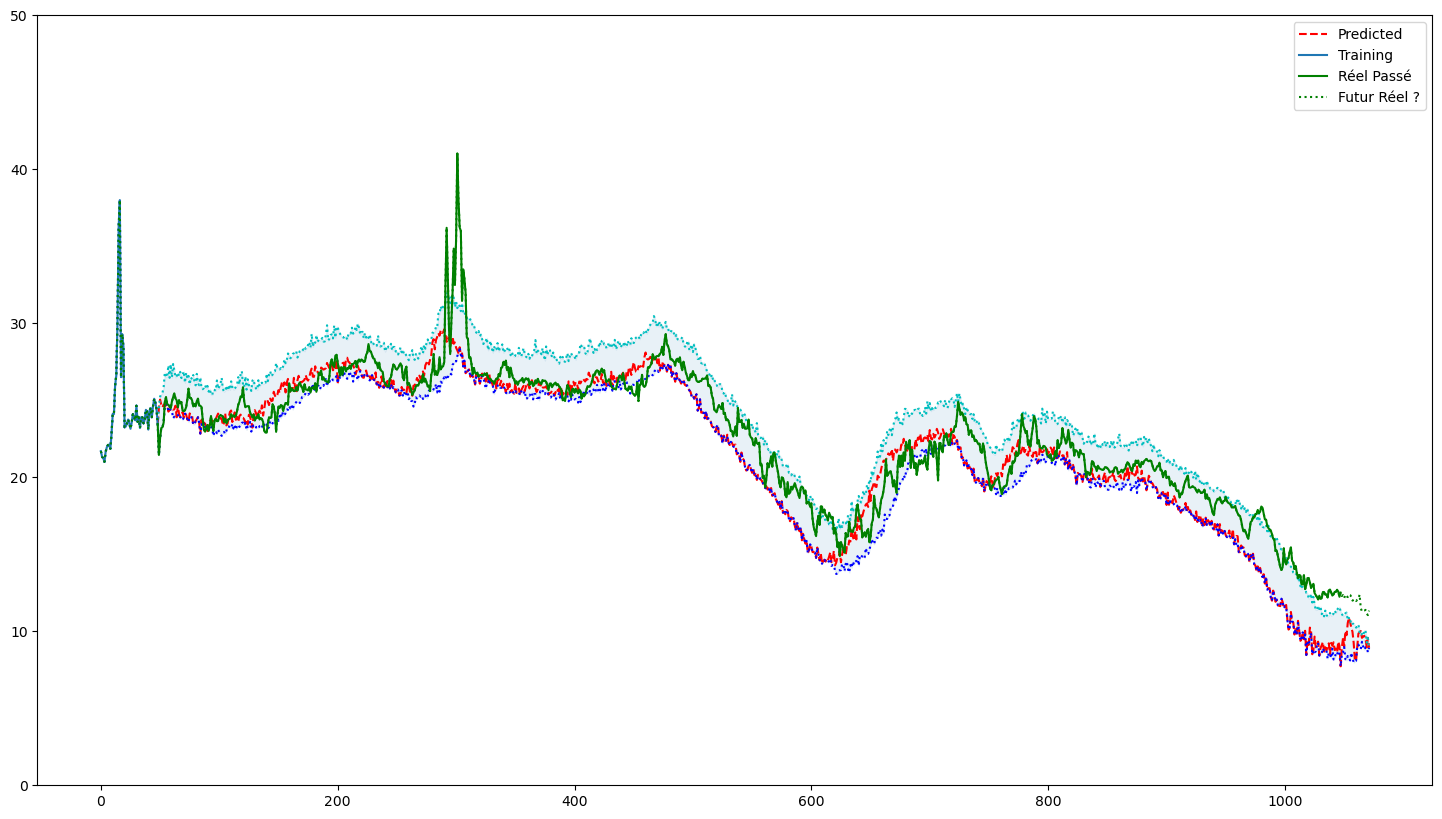

In [9]:
feat=0
v_min = math.ceil( tf.reduce_min(PCimin[:,feat]) / 10.) * 10. - 10.
v_max = math.floor( (math.ceil( tf.reduce_max(x_[:,feat])/10.) * 10) )

deb = SEQ_LEN//2 +1 + forecast
fin = SEQ_LEN - PRED_LEN + forecast
dec_len = SEQ_LEN//2

# -- Affichage ---
fig = plt.figure(figsize=(18,10))
plt.ylim(v_min, v_max )
plt.plot(range(dec_len, fin),PCia[dec_len:fin,feat], 'r--', label="Predicted");
# sns.lineplot(x=range(0,fin),y="Pred", data=df, hue=dfGrp); #,hue=PCimax[:,6]);
plt.plot(range(0, fin),PCimax[0:fin,feat], 'c:');
plt.plot(range(0, fin),PCimin[0:fin,feat], 'b:');
plt.fill_between(x=range(0,fin), y1=PCimax[:,feat], y2=PCimin[:,feat], alpha=0.10, color='tab:blue')
plt.plot(range(0,dec_len+1),x_[0:dec_len+1,feat], label="Training");
plt.plot(range(dec_len,fin-PRED_LEN),x_[dec_len:fin-PRED_LEN,feat], 'g', label="Réel Passé");
plt.plot(range(0,fin),myExpFct.dataFct.data[init:fin+init,feat], 'g:', label="Futur Réel ?");
# plt.plot(range(fin-PRED_LEN,fin),df_raw['OT'][fin+init-PRED_LEN:fin+init], 'g:', label="Futur Réel ?");
plt.legend();

In [ ]:
print(Pia.shape)
print(x_.shape)
print(PCia.shape)


In [ ]:
import pandas as pd
test = myExpFct.dataFct.df_Data[myExpFct.dataFct.df_Data['Day-ahead']<89]
# test = myExpFct.dataFct.df_Data[myExpFct.dataFct.df_Data.loc[['2021-10-04']]==True] #2021-10-04
# test = myExpFct.dataFct.df_Data.loc[[(df_raw['date_m']>='2021-10-04') &(df_raw['date_m']<'2022-12-21')]]
# date = pd.date_range(start='2021-10-04', periods=10)
# test = myExpFct

print(test)